In [2]:
!pip install matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 6.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 8.8 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.2 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 13.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = pd.read_csv('train.csv')
data.head() #prints the first 5 rows of the dataset

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN25630,2,1,2,1,Meal Plan 1,0,Room_Type 1,26,2017,10,17,Online,0,0,0,161.00,0,Not_Canceled
1,INN14474,2,1,1,1,Meal Plan 1,0,Room_Type 1,98,2018,7,16,Online,0,0,0,121.50,2,Not_Canceled
2,INN23721,2,0,0,3,Meal Plan 1,0,Room_Type 1,433,2018,9,8,Offline,0,0,0,70.00,0,Canceled
3,INN05844,2,0,2,5,Meal Plan 1,0,Room_Type 1,195,2018,8,8,Offline,0,0,0,72.25,0,Not_Canceled
4,INN18710,1,0,0,2,Meal Plan 1,0,Room_Type 1,188,2018,6,15,Offline,0,0,0,130.00,0,Canceled


In [31]:
data.shape

(29020, 19)

In [33]:
df = data.copy() #create a copy of the dataset to work with
df.drop(columns=['Booking_ID'], inplace=True)

In [34]:
df.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [36]:
df.duplicated().sum()

7661

In [37]:
df.drop_duplicates(inplace=True)

In [40]:
df.shape

(21359, 18)

In [42]:
df["no_of_adults"].value_counts()

no_of_adults
2    15489
1     3996
3     1748
0      113
4       13
Name: count, dtype: int64

In [44]:
df["no_of_children"].value_counts()

no_of_children
0     19251
1      1257
2       837
3        11
9         2
10        1
Name: count, dtype: int64

In [46]:
df["no_of_weekend_nights"].value_counts()

no_of_weekend_nights
0    9178
1    6063
2    5882
3     110
4      91
5      21
6      14
Name: count, dtype: int64

In [48]:
df["no_of_week_nights"].value_counts()

no_of_week_nights
2     5894
1     5833
3     4628
4     1980
0     1492
5     1169
6      136
7       81
8       43
10      41
9       24
11      12
15       7
12       6
14       5
13       4
16       2
17       2
Name: count, dtype: int64

In [50]:
df["type_of_meal_plan"].value_counts()

type_of_meal_plan
Meal Plan 1     16759
Not Selected     3627
Meal Plan 2       969
Meal Plan 3         4
Name: count, dtype: int64

In [52]:
df["required_car_parking_space"].value_counts()

required_car_parking_space
0    20452
1      907
Name: count, dtype: int64

In [54]:
df["room_type_reserved"].value_counts()

room_type_reserved
Room_Type 1    15375
Room_Type 4     4403
Room_Type 6      758
Room_Type 2      500
Room_Type 5      190
Room_Type 7      129
Room_Type 3        4
Name: count, dtype: int64

In [56]:
df["arrival_year"].value_counts()

arrival_year
2018    18141
2017     3218
Name: count, dtype: int64

In [59]:
df["arrival_month"] #hotel is busy during winter month

0        10
1         7
2         9
3         8
4         6
         ..
29012     6
29013     6
29014    10
29015    12
29019     9
Name: arrival_month, Length: 21359, dtype: int64

In [61]:
df["market_segment_type"].value_counts() #online booking are the mostly used

market_segment_type
Online           16324
Offline           3471
Corporate         1192
Complementary      291
Aviation            81
Name: count, dtype: int64

In [63]:
df["repeated_guest"].value_counts() #most of the guests are not repeated

repeated_guest
0    20667
1      692
Name: count, dtype: int64

In [65]:
df["no_of_previous_cancellations"].value_counts() #most of the guests have no previous cancellation

no_of_previous_cancellations
0     21135
1       115
2        36
3        32
11       20
5        10
4         9
13        1
6         1
Name: count, dtype: int64

In [67]:
df["booking_status"].value_counts() #most of the bookings are not cancelled

booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64

BOOKING_STATUS CLASS IMBALANCE ANALYSIS

Absolute Count:
booking_status
Not_Canceled    15231
Canceled         6128
Name: count, dtype: int64

Percentage Distribution:
booking_status
Not_Canceled    71.309518
Canceled        28.690482
Name: proportion, dtype: float64

Imbalance Ratio (Majority:Minority) = 2.49:1
This means: For every 1 cancelled booking, there are 2.49 not cancelled bookings


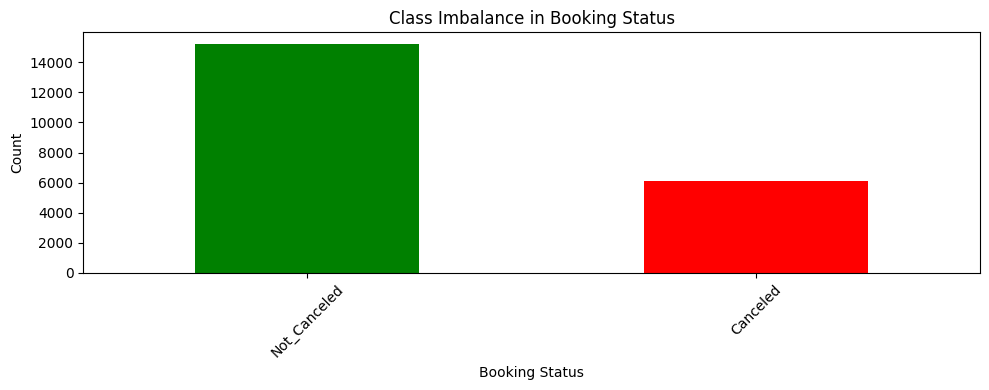

In [82]:
# Visualize the class imbalance
print("=" * 60)
print("BOOKING_STATUS CLASS IMBALANCE ANALYSIS")
print("=" * 60)

# Count of each class
counts = df["booking_status"].value_counts()
print(f"\nAbsolute Count:\n{counts}")

# Percentage distribution
percentages = df["booking_status"].value_counts(normalize=True) * 100
print(f"\nPercentage Distribution:\n{percentages}")

# Imbalance ratio
print(f"\nImbalance Ratio (Majority:Minority) = {counts.iloc[0] / counts.iloc[1]:.2f}:1")
print(f"This means: For every 1 cancelled booking, there are {counts.iloc[0] / counts.iloc[1]:.2f} not cancelled bookings")

# Visualize
plt.figure(figsize=(10, 4))
counts.plot(kind='bar', color=['green', 'red'])
plt.title('Class Imbalance in Booking Status')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Our Data is ImBalanecd

In [80]:
#categorical features

cat_Cols= ['type_of_meal_plan', 'room_type_reserved',
           'required_car_parking_space','market_segment_type',
            'repeated_guest', 'booking_status']

#numerical features
num_Cols = df.columns.difference(cat_Cols)

print(num_Cols.to_list())

len(cat_Cols), len(num_Cols)

['arrival_date', 'arrival_month', 'arrival_year', 'avg_price_per_room', 'lead_time', 'no_of_adults', 'no_of_children', 'no_of_previous_bookings_not_canceled', 'no_of_previous_cancellations', 'no_of_special_requests', 'no_of_week_nights', 'no_of_weekend_nights']


(6, 12)

In [81]:
#skeness on numerical features

skwness = df[num_Cols].skew()
skwness

arrival_date                             0.010333
arrival_month                           -0.293266
arrival_year                            -1.953273
avg_price_per_room                       0.542888
lead_time                                1.405258
no_of_adults                            -0.305652
no_of_children                           4.165696
no_of_previous_bookings_not_canceled    16.735934
no_of_previous_cancellations            22.001489
no_of_special_requests                   0.922373
no_of_week_nights                        1.553657
no_of_weekend_nights                     0.636637
dtype: float64